In [ ]:
# WaveNet: deeper network with more layers to progressively predict next character instead of squashing into 1 hidden layer
'''
Containers:
- organizing layers into lists/dicts
- Sequential -> maintains list of layers (pytorch module)
--- passes given input through all layers sequentially

WaveNet: -> in future reconstruct this myself
- Steps:
--- Take 2 chars from the first layer and fuse them into a bigram
--- Take 2 bigrams and fuse them into a set of 4 chars
--- Take 2 sets of 4 chars and fuse them into a set of 8 chars
--- groups of bigrams in 8 char context processed in parallel
- Uses dilated casual convolutional layers for efficiency
- must make sure batch norm takes the mean over all batch dimensions (before was just taking over first dimension
--- note pytorch assumes 1st index is num channels
- Summary:
--- at this point we're just guessing and checking = bad
--- we're only looking at the training loss (plot we made), but should look at both training and val loss
--- implemented architecture of WaveNet but not forward pass
--- Convolutions:
    - used for efficiency, doesn't change the model
    - instead of calling model on each input, slide model efficiently over input sequence
    - for loops done inside kernals in cuda

How Karpathy builds networks:
- build framework in jupyter notebook to make sure all shapes are working
- paste int vscode to train and run experiments

Parameter log:
- original (3 chars context + 200 hidden neurons, 12K parameters): train: 2.058, val = 2.105
- context 3 -> 8 (22K params): train: 1.918, val: 2.027
- flat -> hierarchical (22K params): train: 1.941, val: 2.029
- fix bug in batchnorm train (22K params): train: 1.912, val: 2.022 -> better bc means and vars estimated w more nums
- scale up network: n_embd = 24, n_hidden = 128 (76K params): train: 1.769, val: 1.993
'''

In [1]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [2]:
words = open('names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [3]:
# build the vocabulary of characters and mappings
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [4]:
# shuffle the words
import random
random.seed(42)
random.shuffle(words)

In [5]:
# build the data set
block_size = 8 # context length: how many chars are considered when predicting the next char

def build_dataset(words):
    X, Y = [],[]

    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context) # stores the context for each char
            Y.append(ix) # stores the char
            context = context[1:] + [ix] # crop and append the new char to context

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1]) # Training set (80%)
Xdev, Ydev = build_dataset(words[n1:n2]) # Dev set (10%)
Xte, Yte = build_dataset(words[n2:]) # Test set (10%)

torch.Size([182580, 8]) torch.Size([182580])
torch.Size([22767, 8]) torch.Size([22767])
torch.Size([22799, 8]) torch.Size([22799])


In [6]:
# Visualize the context of each char in the example
for x, y in zip(Xtr[:20], Ytr[:20]):
    print(''.join(itos[ix.item()] for ix in x), '-->', itos[y.item()])

........ --> e
.......e --> b
......eb --> r
.....ebr --> i
....ebri --> m
...ebrim --> a
..ebrima --> .
........ --> h
.......h --> i
......hi --> l
.....hil --> t
....hilt --> o
...hilto --> n
..hilton --> .
........ --> j
.......j --> h
......jh --> e
.....jhe --> n
....jhen --> e
...jhene --> .


In [7]:
# Training a deeper network - matches pytorch Torch.nn

class Linear:

    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out)) / fan_in**0.5 # initiate with random nums drawn from a gaussian with Kaiming Normal
        self.bias = torch.zeros(fan_out) if bias else None # initiate bias to 0

    def __call__(self, x): # Wx + b
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm1d:

    def __init__(self, dim, eps=1e-5, momentum=0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True # may want to set to false for evaluation mode
        # parameters (trained with backprop)
        self.gamma = torch.ones(dim) # used to scale
        self.beta = torch.zeros(dim) # used to shift
        # buffers (trained with a running 'momentum update' (outside of neural net))
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        # calculate the forward pass
        if self.training: # during training we use batch statistics
            if x.ndim == 2:
                dim = 0
            elif x.ndim == 3: # note pytorch assumes 1st index is num channels
                dim = (0,1) # pass in tuple to take mean/var over the num of neurons in the layer
            xmean = x.mean(dim, keepdim=True) # batch mean
            xvar = x.var(dim, keepdim=True, unbiased=True) # batch variance
        else: # during inference (evaluation) we use the running statistics
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalize to unit variance
        self.out = self.gamma * xhat + self.beta # .out attribute created for modeling, but not typical in pytorch
                                                # Couples activations of across batch elements to control batch statistics
        # update the buffers
        if self.training:
            with torch.no_grad(): # exponential moving average
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []


class Embedding:
  
  def __init__(self, num_embeddings, embedding_dim):
    self.weight = torch.randn((num_embeddings, embedding_dim))
    
  def __call__(self, IX):
    self.out = self.weight[IX]
    return self.out
  
  def parameters(self):
    return [self.weight]

class FlattenConsecutive: # embcat, similar but a little diff than nn.Flatten in pytorch

    def __init__(self, n):
        self.n = n # n = num consecutive elements we want to fuse
    
    def __call__(self,x):
        B, T, C = x.shape
        x = x.view(B, T//self.n, C*self.n)
        if x.shape[1] == 1: # if T//n = 1
            x = x.squeeze(1) # removes dimension
        self.out = x
        return self.out

    def parameters(self):
        return[]

class Sequential:
  
  def __init__(self, layers):
    self.layers = layers
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    self.out = x
    return self.out
  
  def parameters(self):
    # get parameters of all layers and stretch them out into one list
    return [p for layer in self.layers for p in layer.parameters()]

In [8]:
n_embd = 24 # dimensionality of character embedding vector
n_hidden = 128 # num neurons in hidden layer of MLP

model = Sequential([
  Embedding(vocab_size, n_embd),
  FlattenConsecutive(2), Linear(n_embd*2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden*2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  FlattenConsecutive(2), Linear(n_hidden*2, n_hidden, bias=False), BatchNorm1d(n_hidden), Tanh(),
  Linear(n_hidden, vocab_size),
])

with torch.no_grad():
    # last layer: make less confident
    # layers[-1].weight *= 0.1 # linear (no batch norm) last layer
    model.layers[-1].weight *= 0.1 # batch norm last layer
    # all other layers: apply gain

# parameters = [p for layer in layers for p in layer.parameters()]
parameters = model.parameters()
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
    p.requires_grad = True

76579


In [16]:
# Visualize output shapes of each layer
for layer in model.layers:
    print(layer.__class__.__name__, ':', tuple(layer.out.shape))

Embedding : (32, 8, 24)
FlattenConsecutive : (32, 4, 48)
Linear : (32, 4, 128)
BatchNorm1d : (32, 4, 128)
Tanh : (32, 4, 128)
FlattenConsecutive : (32, 2, 256)
Linear : (32, 2, 128)
BatchNorm1d : (32, 2, 128)
Tanh : (32, 2, 128)
FlattenConsecutive : (32, 256)
Linear : (32, 128)
BatchNorm1d : (32, 128)
Tanh : (32, 128)
Linear : (32, 27)


In [10]:
# troubleshooting batchnorm
model.layers[3].running_mean.shape

torch.Size([128])

In [11]:
# matrix multiplication - only works on the last dimension, other dimensions unchanged
(torch.randn(4, 80) @ torch.randn(80,200) + torch.randn(200)).shape

torch.Size([4, 200])

In [12]:
# shape we want for WaveNet - > need to change Flatten layer (concatenation) and linear layer (how many inputs expected)
(torch.randn(4, 4, 20) @ torch.randn(20,200) + torch.randn(200)).shape
# 1st 4 = num examples, 2nd 4 = groups of bigrams

torch.Size([4, 4, 200])

In [13]:
# eplicit concat. same as e.view(4,4,20)

e = torch.randn(4, 8, 10) # goal: want this to be (4, 4, 20) where 10-d vectors get concat.
# e[:, ::2, :] # all elements of 0th dim, even elements of 2nd dim, all parts from last dim
torch.cat([e[:, ::2, :], e[:, 1::2, :]], dim=2).shape # concat across 2nd dim

torch.Size([4, 4, 20])

In [14]:
# Optimization

max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):

    # mini batch construct
    # activations will differ (jitter) between batches because they depend on what other examples are in the batch (which is random)
    # works as a regularizer -> harder to overfit the network
    ix = torch.randint(0, Xtr.shape[0], (batch_size,)) # randomly selects a mini batch size
    Xb, Yb = Xtr[ix], Ytr[ix] # mini batch

    # forward pass
    # emb = C[Xb] # embed the chars into vectors
    # x = emb.view(emb.shape[0], -1) # concatenates the vectors for multiplication
    logits = model(Xb)
    loss = F.cross_entropy(logits, Yb) # loss function

    # backward pass
    for p in parameters:
        p.grad = None # set gradients of parameters to 0
    loss.backward()

    # update
    lr = 0.1 if i < 150000 else 0.01 # step learning rate decay
    for p in parameters:
        p.data += -lr * p.grad # update = learning rate * gradient

    # track stats
    if i % 10000 == 0: # print every 10,000 iterations
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
    lossi.append(loss.log10().item())

      0/ 200000: 3.2773
  10000/ 200000: 2.0065
  20000/ 200000: 2.3056
  30000/ 200000: 2.2198
  40000/ 200000: 2.2910
  50000/ 200000: 2.1900
  60000/ 200000: 1.8032
  70000/ 200000: 1.9261
  80000/ 200000: 1.6199
  90000/ 200000: 1.7918
 100000/ 200000: 1.8918
 110000/ 200000: 2.1114
 120000/ 200000: 1.6584
 130000/ 200000: 1.9256
 140000/ 200000: 1.9280
 150000/ 200000: 1.7540
 160000/ 200000: 1.7504
 170000/ 200000: 1.7421
 180000/ 200000: 1.6665
 190000/ 200000: 1.8735


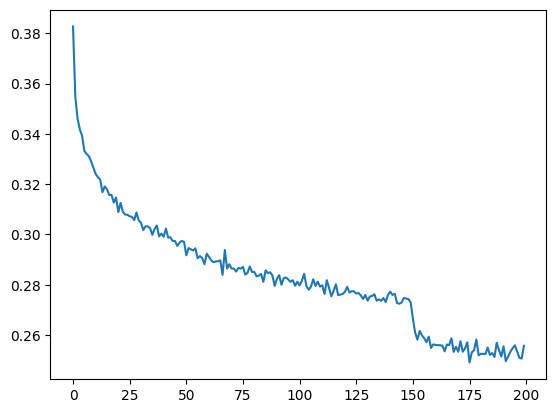

In [15]:
plt.plot(torch.tensor(lossi).view(-1,1000).mean(1)) # plots the mean of every 1000 loss values

In [17]:
# put layers into eval mode (needed for batchnorm especially)
for layer in model.layers:
    layer.training = False

In [18]:
# Evaluate the loss
@torch.no_grad() # this decorator disables gradient tracking for efficiency (not storing all info needed to later do a backward pass)

def split_loss(split): # calculates the loss of each split
    x, y = {
        'train': (Xtr, Ytr),
        'val': (Xdev, Ydev),
        'test': (Xte, Yte),
    }[split]
    logits = model(x)
    loss = F.cross_entropy(logits, y)
    print(split, loss.item())

split_loss('train')
split_loss('val')

train 1.7674086093902588
val 1.9879461526870728


In [19]:
# sample from model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size # initialize with all "..."
    while True:
        # forward pass the neural net
        logits = model(torch.tensor([context]))
        probs = F.softmax(logits, dim=1)

        # sample from distribution
        ix = torch.multinomial(probs, num_samples=1).item()

        # shift the context and track samples
        context = context[1:] + [ix]
        out.append(ix)

        # if we sample '.' then break
        if ix == 0:
            break
    print(''.join(itos[i] for i in out)) # decode and print the generated word

esto.
vanav.
chimari.
joseland.
jvian.
xi.
ziarra.
veem.
nne.
vilson.
avyohn.
mattlayde.
sabina.
jswan.
gaddelyndea.
vidal.
ishaani.
atheriana.
yeric.
evolito.
